# LSTM with daily sentiment + fundamentals-style features

This notebook extends the univariate setup in `LSTMModel1.ipynb`:

1. **One row per trading/calendar day** with engineered columns.
2. **LSTM input** is shape `(batch, time_steps, n_features)` — each time step is a vector `[Close, …]` (all scaled using training data only).
3. **Target** remains next-step **Close** (scaled with its own scaler for clean inverse transform).
4. **Sweep `TIME_STEPS`** to compare how much history the model uses.

**FinBERT teammate notebook** (`finBert_commodity_pipeline_organized (1).ipynb`): after the merge cell it saves `data/processed/merged_for_lstm.csv`. Set `USE_FINBERT_MERGED = True` in the next cell to load that file (daily `price` + FinBERT aggregates, including mean `topic_score` as `topic_confidence_mean`).

Otherwise set `USE_FINBERT_MERGED = False` and use `PRICE_CSV` + `NEWS_CSV`, or rely on synthetic fallback when those files are missing.

The next cells add **FinBERT vs panel checks** (numeric diff should be ~0), **price/sentiment plots**, then **train/val loss** and **predicted vs actual** like `LSTMModel1.ipynb`, plus a **history-length sweep** with RMSE/R² bar charts.

Comments follow the same style as `LSTMModel1.ipynb`: short `#Title case` line comments before each block, plus end-of-line notes on important steps (split, normalise, forward/backward pass, plots).

In [7]:
#Imports: pandas/numpy for the panel, torch for the LSTM, sklearn scaler and metrics, matplotlib for plots (same idea as LSTMModel1)
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

#Primary input: merged CSV from teammate FinBERT notebook (daily sentiment + price)
USE_FINBERT_MERGED = True
FINBERT_MERGED_CSV = os.environ.get(
    "FINBERT_MERGED_CSV",
    str(Path.cwd() / "data" / "processed" / "merged_for_lstm.csv"),
)

#Fallback: separate price file and article-level news CSV if FinBERT export is missing
PRICE_CSV = os.environ.get("PRICE_CSV", "prices.csv")
NEWS_CSV = os.environ.get("NEWS_CSV", "news_sentiment.csv")

#Reproducibility (same seed idea as LSTMModel1)
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [8]:
#Build the daily panel: one row per date, columns = features the LSTM sees (Close + sentiment + lags + vol + placeholders)


def load_or_synth_prices(path: str, n: int = 1200) -> pd.DataFrame:
    """Load date, Close from CSV; if file missing, simulate GBM prices like LSTMModel1."""
    if os.path.isfile(path):
        p = pd.read_csv(path)
        p["date"] = pd.to_datetime(p["date"])
        return p.sort_values("date").reset_index(drop=True)
    #Synthetic GBM path when no CSV (drift, vol, initial price, one trading-day step)
    mu, sigma, S0, dt = 0.05, 0.2, 100.0, 1 / 252
    prices = np.zeros(n)
    prices[0] = S0
    for t in range(1, n):
        r = np.random.normal(mu * dt, sigma * np.sqrt(dt))
        prices[t] = prices[t - 1] * (1 + r)
    d0 = pd.Timestamp("2020-01-01")
    return pd.DataFrame({"date": d0 + pd.to_timedelta(np.arange(n), unit="D"), "Close": prices})


def load_or_synth_news(price_df: pd.DataFrame, path: str) -> pd.DataFrame:
    """Article rows: date, sentiment, optional topic_confidence or topic_score (FinBERT naming)."""
    if os.path.isfile(path):
        n = pd.read_csv(path)
        n["date"] = pd.to_datetime(n["date"]).dt.normalize()
        return n
    #Synthetic headlines on random days (only for testing the pipeline without real news)
    rng = np.random.default_rng(RANDOM_SEED)
    days = price_df["date"].dt.normalize().unique()
    rows = []
    for d in days:
        if rng.random() < 0.35:
            k = int(rng.integers(1, 6))
            for _ in range(k):
                rows.append(
                    {
                        "date": pd.Timestamp(d),
                        "sentiment": float(rng.normal(0, 0.4)),
                        "topic_confidence": float(rng.uniform(0.3, 1.0)),
                    }
                )
    return pd.DataFrame(rows)


def daily_news_features(news: pd.DataFrame) -> pd.DataFrame:
    #Aggregate many headlines per calendar day into one row (mean sentiment, std, count, topic mean)
    if news.empty:
        return pd.DataFrame(columns=["date", "avg_sentiment", "sentiment_std", "news_volume", "topic_confidence_mean"])
    agg = {
        "avg_sentiment": ("sentiment", "mean"),
        "sentiment_std": ("sentiment", "std"),
        "news_volume": ("sentiment", "count"),
    }
    if "topic_confidence" in news.columns:
        agg["topic_confidence_mean"] = ("topic_confidence", "mean")
    elif "topic_score" in news.columns:
        agg["topic_confidence_mean"] = ("topic_score", "mean")
    g = news.groupby("date", as_index=False).agg(**agg)
    if "topic_confidence_mean" not in g.columns:
        g["topic_confidence_mean"] = np.nan
    g["sentiment_std"] = g["sentiment_std"].fillna(0.0)
    return g


def panel_from_finbert_merged_csv(path: str):
    """Read merged_for_lstm.csv: FinBERT daily aggregates already aligned with price (column price renamed to Close)."""
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    if "Close" not in df.columns and "price" in df.columns:
        df = df.rename(columns={"price": "Close"})
    required = ["avg_sentiment", "sentiment_std", "news_volume"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"merged_for_lstm.csv missing columns {missing}. Re-run FinBERT through merge (and daily aggregation).")
    if "topic_confidence_mean" not in df.columns:
        df["topic_confidence_mean"] = 0.0
    df["topic_confidence_mean"] = df["topic_confidence_mean"].fillna(0.0)

    #Return today, lagged return yesterday, 7-day vol known at open (shift so we do not peek at same close)
    df["return_1"] = df["Close"].pct_change()
    df["return_lag1"] = df["return_1"].shift(1)
    df["rolling_vol_7"] = df["return_1"].rolling(7).std().shift(1)

    if "inventory_draw" not in df.columns:
        df["inventory_draw"] = 0.0
    if "production_cut" not in df.columns:
        df["production_cut"] = 0.0
    df["inventory_draw_count"] = df["inventory_draw"].astype(float)
    df["production_cut_count"] = df["production_cut"].astype(float)

    feat_cols = [
        "Close",
        "avg_sentiment",
        "sentiment_std",
        "news_volume",
        "topic_confidence_mean",
        "return_lag1",
        "rolling_vol_7",
        "inventory_draw_count",
        "production_cut_count",
    ]
    #Drop warm-up rows where lag or rolling vol is NaN
    df = df.dropna(subset=["return_lag1", "rolling_vol_7"]).reset_index(drop=True)
    return df, feat_cols


def build_feature_table(price_df: pd.DataFrame, news: pd.DataFrame):
    #Left join news aggregates onto full price calendar; missing news days become neutral zeros
    df = price_df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    daily = daily_news_features(news)
    df = df.merge(daily, on="date", how="left")
    df["avg_sentiment"] = df["avg_sentiment"].fillna(0.0)
    df["sentiment_std"] = df["sentiment_std"].fillna(0.0)
    df["news_volume"] = df["news_volume"].fillna(0).astype(float)
    df["topic_confidence_mean"] = df["topic_confidence_mean"].fillna(0.0)

    df["return_1"] = df["Close"].pct_change()
    df["return_lag1"] = df["return_1"].shift(1)
    df["rolling_vol_7"] = df["return_1"].rolling(7).std().shift(1)

    if "inventory_draw" not in df.columns:
        df["inventory_draw"] = 0.0
    if "production_cut" not in df.columns:
        df["production_cut"] = 0.0
    df["inventory_draw_count"] = df["inventory_draw"].astype(float)
    df["production_cut_count"] = df["production_cut"].astype(float)

    feat_cols = [
        "Close",
        "avg_sentiment",
        "sentiment_std",
        "news_volume",
        "topic_confidence_mean",
        "return_lag1",
        "rolling_vol_7",
        "inventory_draw_count",
        "production_cut_count",
    ]
    df = df.dropna(subset=["return_lag1", "rolling_vol_7"]).reset_index(drop=True)
    return df, feat_cols


#Choose data source: FinBERT merged file if present, else synthetic / price + news path
if USE_FINBERT_MERGED and os.path.isfile(FINBERT_MERGED_CSV):
    panel, FEATURE_COLS = panel_from_finbert_merged_csv(FINBERT_MERGED_CSV)
    print("Loaded FinBERT merged:", FINBERT_MERGED_CSV)
else:
    if USE_FINBERT_MERGED:
        print("FinBERT CSV missing — fallback to PRICE_CSV / synthetic:", FINBERT_MERGED_CSV)
    price_df = load_or_synth_prices(PRICE_CSV)
    news_df = load_or_synth_news(price_df, NEWS_CSV)
    panel, FEATURE_COLS = build_feature_table(price_df, news_df)

print(panel.tail(3))
print("Features:", FEATURE_COLS)
print("Panel rows:", len(panel), "| date range:", panel["date"].min(), "→", panel["date"].max())


Loaded FinBERT merged: /Users/mandarjoshi/Desktop/SUTD_Term_6/Computational Data Science/ProjectModels/data/processed/merged_for_lstm.csv
          date  avg_sentiment  median_sentiment  sentiment_std  max_sentiment  \
209 2023-08-06       0.339393         -0.171542       0.391324       0.067849   
210 2023-08-07      -0.015921         -0.169000       0.121782       0.137086   
211 2023-08-08      -0.135609          0.149061       0.240090       0.395664   

     min_sentiment  news_volume  sentiment_volume_weighted  \
209      -0.213335            1                   0.036242   
210      -0.050414            8                  -0.149567   
211      -0.482916            4                  -0.115379   

     topic_confidence_mean      Close  return_1  return_lag1  rolling_vol_7  \
209               0.598993  71.066645 -0.002756    -0.000035       0.004836   
210               0.598626  70.762979 -0.004273    -0.002756       0.005139   
211               0.759878  71.836092  0.015165    


=== FinBERT data check (merged CSV ↔ LSTM panel) ===
  avg_sentiment: max |panel − csv| = 0  (should be ~0)
  sentiment_std: max |panel − csv| = 0  (should be ~0)
  news_volume: max |panel − csv| = 0  (should be ~0)
  topic_confidence_mean: max |panel − csv| = 0  (should be ~0)

Correlations (Pearson, panel) — sentiment vs Close / returns:
  avg_sentiment          vs ret_fwd1: +0.0250  vs Close: +0.0290
  sentiment_std          vs ret_fwd1: +0.0621  vs Close: -0.1132
  news_volume            vs ret_fwd1: -0.0630  vs Close: +0.1534
  topic_confidence_mean  vs ret_fwd1: +0.0626  vs Close: +0.0019

Share of days with news_volume > 0: 100.0%
If correlations are ~0, sentiment may still be 'correct' but not predictive of next-day returns.



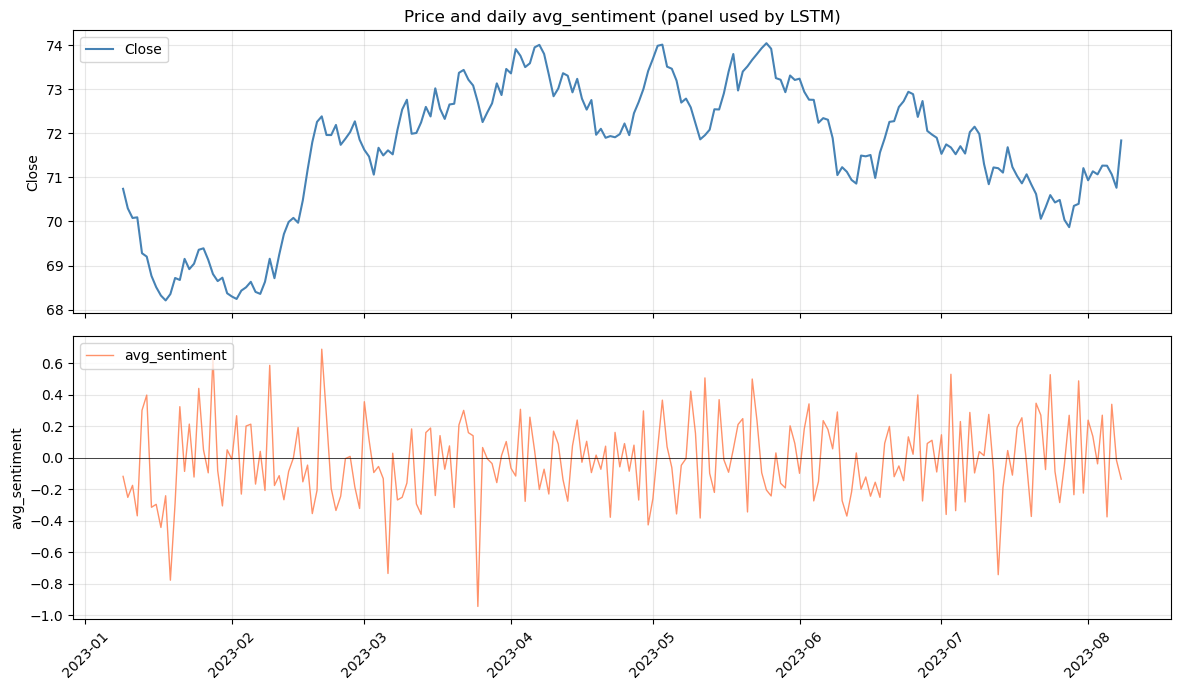

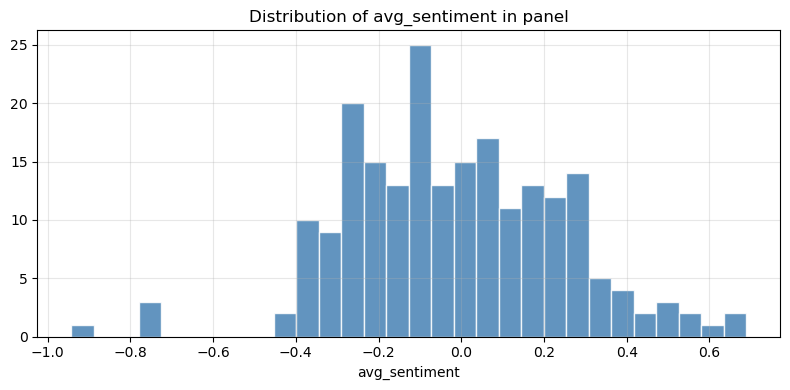

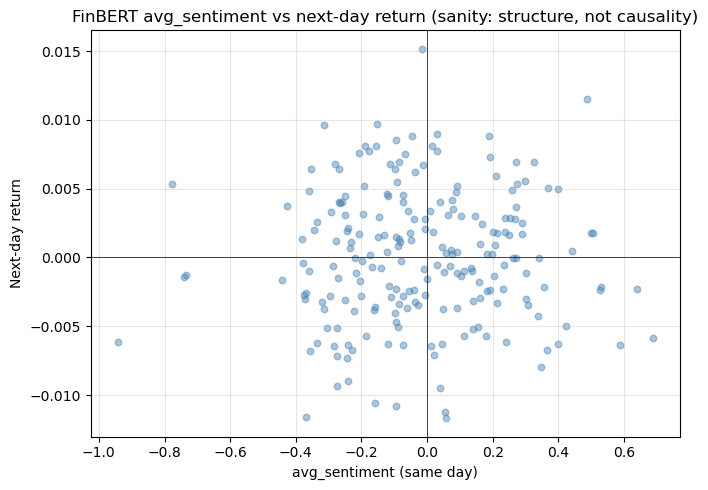

In [12]:
#FinBERT sanity checks and quick plots (verify CSV columns match panel; eyeball sentiment vs price)

SENTINEL_COLS = ["avg_sentiment", "sentiment_std", "news_volume", "topic_confidence_mean"]


def finbert_merge_sanity(merged_csv: str, panel_df: pd.DataFrame) -> None:
    print("\n=== FinBERT data check (merged CSV ↔ LSTM panel) ===")
    if not os.path.isfile(merged_csv):
        print("Skipped: file not found (using synthetic / fallback path).")
        return
    raw = pd.read_csv(merged_csv)
    raw["date"] = pd.to_datetime(raw["date"]).dt.normalize()
    for c in SENTINEL_COLS:
        if c not in raw.columns:
            print(f"WARNING: column '{c}' missing from merged CSV.")
    key = ["date"] + [c for c in SENTINEL_COLS if c in raw.columns and c in panel_df.columns]
    if len(key) < 2:
        print("Not enough overlapping columns to compare.")
        return
    #Inner join on date; compare panel column to CSV column renamed with _csv suffix
    chk = panel_df[key].merge(raw[key].rename(columns={c: f"{c}_csv" for c in key[1:]}), on="date", how="inner")
    if chk.empty:
        print("WARNING: no matching dates between panel and CSV (check date parsing).")
        return
    for c in key[1:]:
        d = (chk[c] - chk[f"{c}_csv"]).abs()
        print(f"  {c}: max |panel − csv| = {d.max():.6g}  (should be ~0)")
    #Pearson correlations: weak values are common; they do not by themselves mean the pipeline is broken
    p = panel_df.copy()
    if "return_1" not in p.columns:
        p["return_1"] = p["Close"].pct_change()
    p["ret_fwd1"] = p["return_1"].shift(-1)
    corr_cols = ["Close", "return_1", "ret_fwd1"] + [c for c in SENTINEL_COLS if c in p.columns]
    cmat = p[corr_cols].corr(numeric_only=True)
    print("\nCorrelations (Pearson, panel) — sentiment vs Close / returns:")
    for c in SENTINEL_COLS:
        if c in cmat.index:
            a = cmat.loc[c, "ret_fwd1"] if "ret_fwd1" in cmat.columns else float("nan")
            b = cmat.loc[c, "Close"] if "Close" in cmat.columns else float("nan")
            sa = f"{a:+.4f}" if pd.notna(a) else "nan"
            sb = f"{b:+.4f}" if pd.notna(b) else "nan"
            print(f"  {c:22s} vs ret_fwd1: {sa}  vs Close: {sb}")
    nz = (p["news_volume"] > 0).mean()
    print(f"\nShare of days with news_volume > 0: {nz:.1%}")
    print("If correlations are ~0, sentiment may still be 'correct' but not predictive of next-day returns.\n")


if USE_FINBERT_MERGED and os.path.isfile(FINBERT_MERGED_CSV):
    finbert_merge_sanity(FINBERT_MERGED_CSV, panel)

#First plot: Close over time and daily avg_sentiment (features the LSTM sees)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax0, ax1 = axes
ax0.plot(panel["date"], panel["Close"], color="steelblue", lw=1.5, label="Close")
ax0.set_ylabel("Close")
ax0.legend(loc="upper left")
ax0.set_title("Price and daily avg_sentiment (panel used by LSTM)")
ax0.grid(True, alpha=0.3)
ax1.plot(panel["date"], panel["avg_sentiment"], color="coral", lw=1, alpha=0.85, label="avg_sentiment")
ax1.axhline(0, color="k", lw=0.5)
ax1.set_ylabel("avg_sentiment")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Second plot: histogram of avg_sentiment (spot stuck-at-zero or odd spikes)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(panel["avg_sentiment"].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_title("Distribution of avg_sentiment in panel")
ax.set_xlabel("avg_sentiment")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Third plot: scatter same-day sentiment vs next-day return (exploratory only)
p2 = panel.copy()
p2["ret_fwd1"] = p2["Close"].pct_change().shift(-1)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(p2["avg_sentiment"], p2["ret_fwd1"], alpha=0.45, s=22, color="steelblue")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("avg_sentiment (same day)")
ax.set_ylabel("Next-day return")
ax.set_title("FinBERT avg_sentiment vs next-day return (sanity: structure, not causality)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Epoch [10/50] - Train Loss: 0.015334 - Val Loss: 0.018357
Epoch [20/50] - Train Loss: 0.015516 - Val Loss: 0.009597
Epoch [30/50] - Train Loss: 0.013768 - Val Loss: 0.008759
Epoch [40/50] - Train Loss: 0.011981 - Val Loss: 0.006777
Epoch [50/50] - Train Loss: 0.010602 - Val Loss: 0.004246
Training complete!
Effective TIME_STEPS=60 | train seq=109 | val tail=11 | test seq=43
Test RMSE: 1.1415  MAE: 1.0160  R²: -2.2613
(R² > 0 means better than predicting the constant mean Close on the test window.)


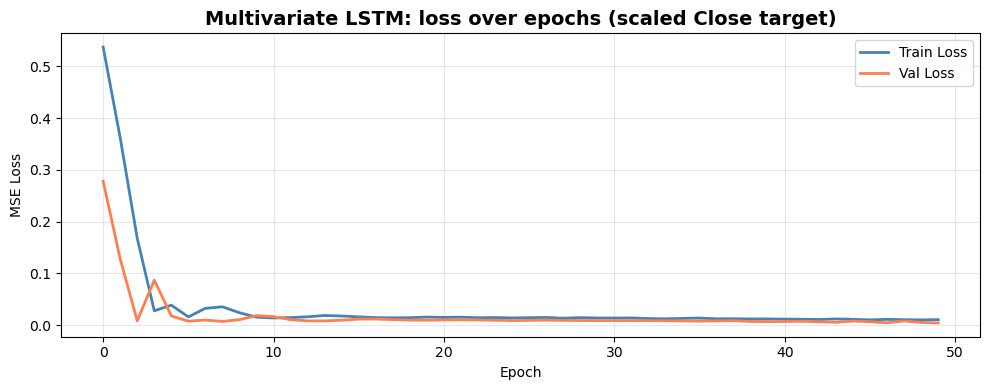

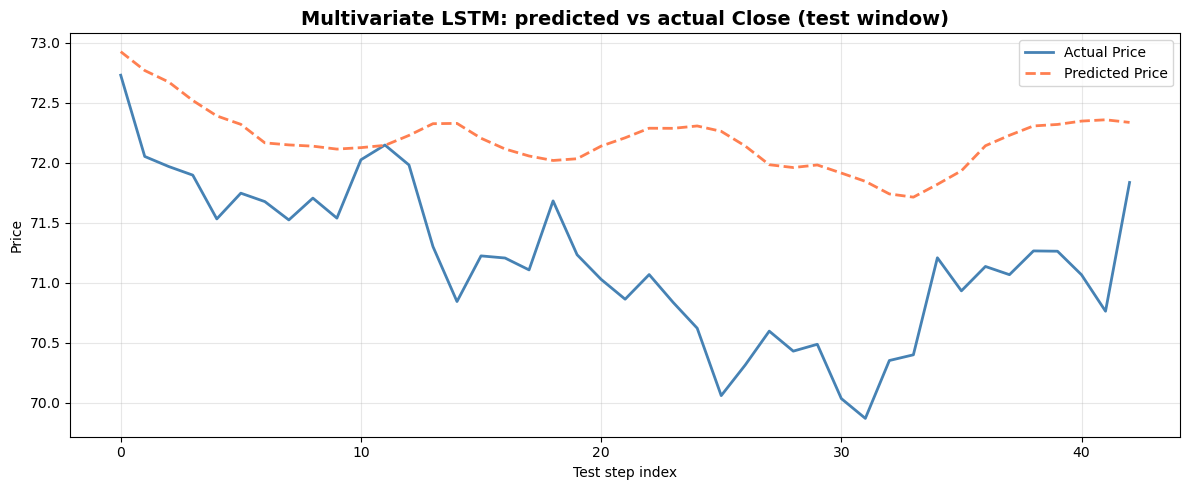

In [13]:
#Multivariate LSTM: sliding windows over all features, predict next-day Close (scaled MinMax like univariate notebook)


def create_sequences_multifeature(data: np.ndarray, time_steps: int, target_col: int = 0):
    #Each sample: rows [i : i+time_steps] as input, row i+time_steps target_col as target (next step Close)
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps, target_col])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)


class LSTMModel(nn.Module):
    #Same architecture idea as LSTMModel1: stacked LSTM then linear head; dropout between LSTM layers

    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, output_size: int = 1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        #Use last time step hidden output for prediction (many-to-one)
        return self.fc(out[:, -1, :])


def train_eval_one(panel: pd.DataFrame, feat_cols: list, time_steps: int, epochs: int = 50, batch_size: int = 32, lr: float = 1e-3):
    target_col_idx = feat_cols.index("Close")
    raw = panel[feat_cols].values.astype(np.float64)
    #Chronological split: first 80% dates train, last 20% test (no shuffle — order matters for time series)
    split_idx = int(len(panel) * 0.8)
    train_raw = raw[:split_idx]
    test_raw = raw[split_idx:]
    #Clamp window length so we always have at least a few training sequences
    time_steps = int(min(time_steps, max(1, len(train_raw) - 2)))

    #Normalise using only the training rows (same leakage rule as LSTMModel1)
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    train_mat = scaler_X.fit_transform(train_raw)
    test_mat = scaler_X.transform(test_raw)

    #Training sequences built entirely inside train_mat
    X_tr, y_tr = create_sequences_multifeature(train_mat, time_steps, target_col_idx)
    #Test sequences: prepend last time_steps rows of train so first test day has full history
    bridge = np.vstack([train_mat[-time_steps:], test_mat])
    X_te, y_te = create_sequences_multifeature(bridge, time_steps, target_col_idx)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)
    Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
    yv = torch.tensor(y_te, dtype=torch.float32, device=device)

    #Validation split: last 10% of training sequences (still before test period)
    val_split = int(len(Xt) * 0.9)
    X_train, y_train = Xt[:val_split], yt[:val_split]
    X_val, y_val = Xt[val_split:], yt[val_split:]

    model = LSTMModel(input_size=len(feat_cols)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)

    train_losses, val_losses = [], []
    for ep in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            opt.zero_grad()  #Resetting the gradients to zero before computing the new gradients
            predictions = model(xb)  #Forward pass — predictions from the model
            loss = crit(predictions, yb)  #Computing the error (MSE) between predicted and actual scaled Close
            loss.backward()  #Backward pass
            opt.step()  #Updating the model parameters based on the computed gradients
            epoch_loss += loss.item() * len(xb)  #Accumulating the loss for the current epoch
        tr = epoch_loss / max(1, len(X_train))  #Average loss for this epoch
        train_losses.append(tr)  #Store training loss for plotting
        model.eval()
        with torch.no_grad():  #Tells PyTorch to not track gradients for this block
            vl = crit(model(X_val), y_val).item()  #Validation loss on held-out train tail
        val_losses.append(vl)  #Store validation loss for plotting
        if (ep + 1) % 10 == 0:
            print(f"Epoch [{ep+1}/{epochs}] - Train Loss: {tr:.6f} - Val Loss: {vl:.6f}")
    print("Training complete!")

    #Test-set predictions (scaled target); map back to price with inverse transform on Close column only
    model.eval()
    with torch.no_grad():
        pred = model(Xv).cpu().numpy()
    y_true = yv.cpu().numpy()
    n_feat = train_raw.shape[1]

    def invert_close(col0_scaled):
        pad = np.zeros((len(col0_scaled), n_feat))
        pad[:, target_col_idx] = col0_scaled.ravel()
        return scaler_X.inverse_transform(pad)[:, target_col_idx].reshape(-1, 1)

    pred_price = invert_close(pred)
    act_price = invert_close(y_true)
    rmse = float(np.sqrt(mean_squared_error(act_price, pred_price)))
    mae = float(mean_absolute_error(act_price, pred_price))
    r2 = float(r2_score(act_price, pred_price))
    return {
        "time_steps": time_steps,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "pred_price": pred_price,
        "act_price": act_price,
        "n_train_sequences": int(len(Xt)),
        "n_val_train_tail": int(len(X_val)),
        "n_test_sequences": int(len(pred_price)),
    }


#Default run: history length TIME_STEPS, then same style of plots as LSTMModel1
EPOCHS = 50
BATCH_SIZE = 32
TIME_STEPS = 60
res = train_eval_one(panel, FEATURE_COLS, TIME_STEPS, epochs=EPOCHS, batch_size=BATCH_SIZE)
print(
    f"Effective TIME_STEPS={res['time_steps']} | train seq={res['n_train_sequences']} "
    f"| val tail={res['n_val_train_tail']} | test seq={res['n_test_sequences']}"
)
print(f"Test RMSE: {res['rmse']:.4f}  MAE: {res['mae']:.4f}  R²: {res['r2']:.4f}")
print("(R² > 0 means better than predicting the constant mean Close on the test window.)")

#First plot: training and validation loss over epochs
plt.figure(figsize=(10, 4))
plt.plot(res["train_losses"], label="Train Loss", color="steelblue", linewidth=2)
plt.plot(res["val_losses"], label="Val Loss", color="coral", linewidth=2)
plt.title("Multivariate LSTM: loss over epochs (scaled Close target)", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Second plot: predicted vs actual prices on the test window
plt.figure(figsize=(12, 5))
plt.plot(res["act_price"], label="Actual Price", color="steelblue", linewidth=2)
plt.plot(res["pred_price"], label="Predicted Price", color="coral", linewidth=2, linestyle="--")
plt.title("Multivariate LSTM: predicted vs actual Close (test window)", fontsize=14, fontweight="bold")
plt.xlabel("Test step index")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Panel rows=212, train days=169, max TIME_STEPS allowed=167

Epoch [10/50] - Train Loss: 0.045152 - Val Loss: 0.011110
Epoch [20/50] - Train Loss: 0.018217 - Val Loss: 0.006902
Epoch [30/50] - Train Loss: 0.013518 - Val Loss: 0.003598
Epoch [40/50] - Train Loss: 0.009577 - Val Loss: 0.003102
Epoch [50/50] - Train Loss: 0.007765 - Val Loss: 0.003999
Training complete!
Epoch [10/50] - Train Loss: 0.018581 - Val Loss: 0.025368
Epoch [20/50] - Train Loss: 0.015540 - Val Loss: 0.013930
Epoch [30/50] - Train Loss: 0.014469 - Val Loss: 0.013094
Epoch [40/50] - Train Loss: 0.013101 - Val Loss: 0.011127
Epoch [50/50] - Train Loss: 0.009889 - Val Loss: 0.006471
Training complete!
Epoch [10/50] - Train Loss: 0.014326 - Val Loss: 0.021383
Epoch [20/50] - Train Loss: 0.015846 - Val Loss: 0.009073
Epoch [30/50] - Train Loss: 0.014875 - Val Loss: 0.008311
Epoch [40/50] - Train Loss: 0.012563 - Val Loss: 0.007276
Epoch [50/50] - Train Loss: 0.010930 - Val Loss: 0.005448
Training complete!
Epoch [10/50]

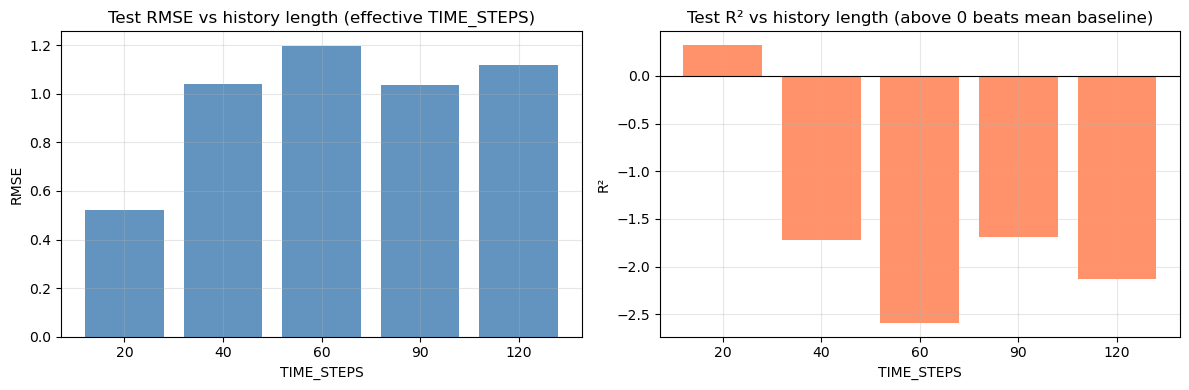

In [15]:
#Sweep different history lengths (TIME_STEPS); same train/test split, retrain from scratch each time

candidates = [20, 40, 60, 90, 120]
rows = []
split_idx = int(len(panel) * 0.8)
max_ts = max(1, split_idx - 2)
print(f"Panel rows={len(panel)}, train days={split_idx}, max TIME_STEPS allowed={max_ts}\n")
for ts in candidates:
    if ts > max_ts:
        print(f"  skip TIME_STEPS={ts} (need ≤ {max_ts} for this panel)")
        continue
    out = train_eval_one(panel, FEATURE_COLS, ts, epochs=EPOCHS, batch_size=BATCH_SIZE)
    rows.append(
        {
            "requested_ts": ts,
            "effective_ts": out["time_steps"],
            "n_test_seq": out["n_test_sequences"],
            "rmse": out["rmse"],
            "mae": out["mae"],
            "r2": out["r2"],
        }
    )

sweep_df = pd.DataFrame(rows)
print(sweep_df.to_string(index=False))

if not sweep_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = sweep_df["effective_ts"].astype(str)
    axes[0].bar(x, sweep_df["rmse"], color="steelblue", alpha=0.85)
    axes[0].set_title("Test RMSE vs history length (effective TIME_STEPS)")
    axes[0].set_xlabel("TIME_STEPS")
    axes[0].set_ylabel("RMSE")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(x, sweep_df["r2"], color="coral", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.8)
    axes[1].set_title("Test R² vs history length (above 0 beats mean baseline)")
    axes[1].set_xlabel("TIME_STEPS")
    axes[1].set_ylabel("R²")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
